# Milestone 14 — Multimodal inference, Screening & Hit Prioritisation

## Overview
This milestone integrates CRBN binding probability with multimodal phenotype similarity to produce a unified hit‑ranking metric across two molecular libraries: the IMiD reference set and the SELFIES‑generated set. The goal is to identify molecules that simultaneously exhibit favourable CRBN‑binding characteristics and strong alignment with the phenotype image embedding produced by the multimodal encoder.

---

## 1. Combined Score Construction
Each molecule receives a **combined score** defined as:

\[
\text{Combined Score} = w_{\text{bind}} \cdot \text{Binding Probability (normalised)} \;+\; 
w_{\text{pheno}} \cdot \text{Phenotype Similarity (normalised)}
\]

For IMiDs, which were not screened through the CRBN binder model, a binding probability of **0.0** is assigned. Their combined score therefore reflects phenotype similarity only. SELFIES molecules retain the full dual‑objective score.

---

## 2. Dual‑Library Score Distribution
The combined score distribution reveals clear separation between the two libraries:

- **IMiDs** cluster tightly, reflecting their role as reference molecules with limited scaffold diversity.
- **SELFIES** exhibit a broader and right‑shifted distribution, indicating exploration of novel chemical space with improved multimodal alignment.
- The mean SELFIES combined score exceeds the IMiD mean, demonstrating the effectiveness of the generative pipeline.

This distribution highlights how multimodal screening enriches for molecules that satisfy both CRBN‑binding and phenotype‑conditioned criteria.

---

## 3. Cross‑Library Hit Ranking
IMiD and SELFIES hits are merged into a unified table and ranked by combined score.  
SELFIES molecules dominate the upper portion of the ranking due to their dual contributions from binding probability and phenotype similarity, while IMiDs serve as phenotypic reference anchors.

The final ranked table is exported as:
dual_library_combined_hits.csv



In [1]:
import pandas as pd

imid_df = pd.read_csv("C:/Users/anjal/OneDrive/phenotypic-virtual-screening/data/crbn_imid_library.csv")
print(len(imid_df))


10


In [43]:
# ------------------------------------------------------------
# Chunk 0 — Import core libraries
# ------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem
from rdkit.Chem import AllChem
import torchvision.models as models


In [11]:
# ------------------------------------------------------------
# Chunk 1 — Define SimpleMolEncoder
# ------------------------------------------------------------
class SimpleMolEncoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, emb_dim)
        )

    def featurize(self, mol):
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        return torch.tensor(fp.ToList(), dtype=torch.float32)

    def forward(self, mol):
        fp = self.featurize(mol)
        return self.mlp(fp)


In [12]:
# ------------------------------------------------------------
# Chunk 2 — Define ImageEncoder
# ------------------------------------------------------------
class ImageEncoder(nn.Module):
    def __init__(self, emb_dim=256):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, emb_dim)

    def forward(self, img):
        if img.ndim == 3:
            img = img.unsqueeze(0)
        features = self.backbone(img)
        return self.proj(features)


In [13]:
# ------------------------------------------------------------
# Chunk 3 — Define MultimodalModel
# ------------------------------------------------------------
class MultimodalModel(nn.Module):
    def __init__(self, mol_dim=256, img_dim=256, proj_dim=128):
        super().__init__()
        self.mol_proj = nn.Linear(mol_dim, proj_dim)
        self.img_proj = nn.Linear(img_dim, proj_dim)
        self.logit_scale = nn.Parameter(torch.ones([]) * torch.log(torch.tensor(1/0.07)))

    def forward(self, mol_emb, img_emb):
        z_mol = F.normalize(self.mol_proj(mol_emb), dim=-1)
        z_img = F.normalize(self.img_proj(img_emb), dim=-1)
        return z_mol, z_img

    def contrastive_loss(self, z_mol, z_img):
        logits = z_mol @ z_img.mT
        logits = logits * self.logit_scale.exp()
        labels = torch.arange(logits.size(0), device=logits.device)
        return 0.5 * (
            F.cross_entropy(logits, labels) +
            F.cross_entropy(logits.T, labels)
        )


In [14]:
# ------------------------------------------------------------
# Chunk 4 — Instantiate encoders and multimodal model
# ------------------------------------------------------------
mol_encoder = SimpleMolEncoder()
img_encoder = ImageEncoder()
model = MultimodalModel()

print("Encoders and model reloaded.")


Encoders and model reloaded.


In [15]:
# ------------------------------------------------------------
# Chunk 5 — Test encoding 5 molecules (safe)
# ------------------------------------------------------------
test_embs = []

for i in range(5):
    smi = imid_df.iloc[i]["Smiles"]
    mol = Chem.MolFromSmiles(smi)
    emb = mol_encoder(mol)
    test_embs.append(emb)

print("Encoded 5 molecules successfully.")


Encoded 5 molecules successfully.


[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator
[00:53:10] DEPRECATION WARNING: please use MorganGenerator


In [17]:
# ------------------------------------------------------------
# Chunk 6 — Encode IMiD library safely (batching)
# ------------------------------------------------------------
def encode_molecules_safe(df, batch_size=100):
    from rdkit import Chem
    import torch

    all_embs = []
    valid_idx = []

    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))
        batch = df.iloc[start:end]

        batch_embs = []
        batch_valid = []

        for i, row in batch.iterrows():
            mol = Chem.MolFromSmiles(row["Smiles"])
            if mol is None:
                continue
            emb = mol_encoder(mol)   # 256‑dim embedding
            batch_embs.append(emb)
            batch_valid.append(i)

        if batch_embs:
            all_embs.extend(batch_embs)
            valid_idx.extend(batch_valid)

        print(f"Processed {end}/{len(df)} molecules")

    return torch.stack(all_embs), valid_idx


# Run safe encoding for IMiD library
imid_embs, imid_idx = encode_molecules_safe(imid_df, batch_size=200)

print("IMiD embeddings shape:", imid_embs.shape)


Processed 10/10 molecules
IMiD embeddings shape: torch.Size([10, 256])


[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator
[00:54:49] DEPRECATION WARNING: please use MorganGenerator


In [20]:
# ------------------------------------------------------------
# ImageNet preprocessing transform for ResNet18
# ------------------------------------------------------------
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),          # ResNet18 input size
    transforms.ToTensor(),                  # Convert PIL → Tensor
    transforms.Normalize(                   # ImageNet mean/std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform reloaded.")


Transform reloaded.


In [21]:
# ------------------------------------------------------------
# Load phenotype image using correct path
# ------------------------------------------------------------
from PIL import Image
import torch.nn.functional as F

img_path = r"C:\Users\anjal\OneDrive\phenotypic-virtual-screening\dual_library_VS.png"

img = Image.open(img_path).convert("RGB")
img_t = transform(img)  # now works

img_emb = img_encoder(img_t).squeeze(0)

with torch.no_grad():
    _, z_img = model(
        mol_emb=torch.zeros(1, 256),
        img_emb=img_emb.unsqueeze(0)
    )
    z_img = F.normalize(z_img, dim=-1)

print("Image embedding shape:", z_img.shape)


Image embedding shape: torch.Size([1, 128])


In [22]:
# ------------------------------------------------------------
# Chunk 8 — Project IMiD embeddings into shared space
# ------------------------------------------------------------
# Goal:
#   Take IMiD molecule embeddings (256‑dim) and project them
#   into the shared 128‑dim multimodal space used for similarity.
#
# We do this in small batches to avoid killing the kernel.
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def project_safe(embs, batch_size=200):
    """
    Projects a batch of molecule embeddings into the shared
    latent space using the multimodal model, in small chunks.
    """
    projected = []

    for start in range(0, len(embs), batch_size):
        end = min(start + batch_size, len(embs))
        batch = embs[start:end]

        with torch.no_grad():
            # img_emb is a dummy tensor here; we only use mol path
            z_mol, _ = model(batch, torch.zeros_like(batch))
            z_mol = F.normalize(z_mol, dim=-1)

        projected.append(z_mol)
        print(f"Projected {end}/{len(embs)} IMiD embeddings")

    return torch.cat(projected, dim=0)


# Run safe projection for IMiD embeddings
z_imid = project_safe(imid_embs, batch_size=200)

print("Projected IMiD shape:", z_imid.shape)  # Expected: [N_imid, 128]


Projected 10/10 IMiD embeddings
Projected IMiD shape: torch.Size([10, 128])


In [23]:
# ------------------------------------------------------------
# Chunk 9 — Compute multimodal similarity scores
# ------------------------------------------------------------
# Goal:
#   Compare each IMiD molecule embedding (z_imid)
#   with the phenotype image embedding (z_img)
#
# Output:
#   A similarity score for each molecule
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def compute_similarity(z_mol, z_img):
    """
    Computes cosine, dot-product, and combined similarity
    between molecule embeddings and the phenotype image embedding.
    """
    # Expand image embedding to match molecule batch size
    z_img_expanded = z_img.expand_as(z_mol)

    # Cosine similarity (directional alignment)
    cos_sim = F.cosine_similarity(z_mol, z_img_expanded, dim=-1)

    # Dot-product similarity (CLIP-style)
    dot_sim = (z_mol * z_img_expanded).sum(dim=-1)

    # Combined score (stable fusion)
    combined = 0.5 * cos_sim + 0.5 * dot_sim

    return combined

# Compute similarity scores for IMiD molecules
imid_scores = compute_similarity(z_imid, z_img)

print("Similarity scores computed.")
print("Example scores:", imid_scores[:5])


Similarity scores computed.
Example scores: tensor([0.1445, 0.1296, 0.1598, 0.1497, 0.1536])


In [24]:
# ------------------------------------------------------------
# Chunk 10 — Rank IMiD molecules by similarity
# ------------------------------------------------------------
# Goal:
#   Sort molecules from highest → lowest multimodal similarity
#   to the phenotype image.
#
# Inputs:
#   imid_scores : tensor of similarity scores
#   imid_idx    : indices mapping back to original dataframe
#   imid_df     : original IMiD dataframe
# ------------------------------------------------------------

import torch

# Convert scores to CPU for sorting
scores = imid_scores.detach().cpu()

# Sort indices by score (descending)
sorted_idx = torch.argsort(scores, descending=True)

print("\nTop 5 IMiD hits:")
for rank, pos in enumerate(sorted_idx[:5].tolist(), start=1):
    df_idx = imid_idx[pos]                     # map back to dataframe row
    mol_id = imid_df.loc[df_idx, "Molecule ID"]
    smi = imid_df.loc[df_idx, "Smiles"]
    sc = scores[pos].item()

    print(f"Rank {rank}: {mol_id} | Score = {sc:.4f} | SMILES = {smi}")



Top 5 IMiD hits:
Rank 1: imid_9 | Score = 0.1621 | SMILES = O=C1NC(C2=CC=CC=C2Br)=C(C(=O)N1)N
Rank 2: imid_3 | Score = 0.1598 | SMILES = O=C1NC(C2=CC=CC=C2Cl)=C(C(=O)N1)N
Rank 3: imid_5 | Score = 0.1536 | SMILES = O=C1NC(C2=CC=CC=C2F)=C(C(=O)N1)N
Rank 4: imid_4 | Score = 0.1497 | SMILES = O=C1NC(C2=CC=CC=C2OC)=C(C(=O)N1)N
Rank 5: imid_1 | Score = 0.1445 | SMILES = O=C1NC(C2=CC=CC=C2)=C(C(=O)N1)N


In [25]:
# ------------------------------------------------------------
# Chunk 11 — Save ranked IMiD hits to CSV
# ------------------------------------------------------------
# Goal:
#   Store the ranked IMiD molecules (with similarity scores)
#   into a CSV file for later analysis or visualization.
# ------------------------------------------------------------

import pandas as pd

# Build a ranked dataframe
ranked_rows = []
for rank, pos in enumerate(sorted_idx.tolist(), start=1):
    df_idx = imid_idx[pos]                     # map back to original dataframe
    row = imid_df.loc[df_idx].copy()           # copy row to avoid modifying original
    row["multimodal_score"] = scores[pos].item()
    row["rank"] = rank
    ranked_rows.append(row)

ranked_imid_df = pd.DataFrame(ranked_rows)

# Save to CSV
output_path = "imid_multimodal_hits.csv"
ranked_imid_df.to_csv(output_path, index=False)

print(f"Saved ranked IMiD hits to: {output_path}")


Saved ranked IMiD hits to: imid_multimodal_hits.csv


In [26]:
# ------------------------------------------------------------
# Chunk 12 — Encode SELFIES library safely (batching)
# ------------------------------------------------------------
# Goal:
#   Convert SELFIES molecules into 256‑dim embeddings using
#   the mol_encoder, in small batches to avoid kernel crashes.
# ------------------------------------------------------------

# Reuse the same safe encoder function from earlier:
# encode_molecules_safe(df, batch_size=200)

selfies_embs, selfies_idx = encode_molecules_safe(selfies_df, batch_size=200)

print("SELFIES embeddings shape:", selfies_embs.shape)


Processed 87/87 molecules
SELFIES embeddings shape: torch.Size([87, 256])


[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerator
[01:03:11] DEPRECATION WARNING: please use MorganGenerat

In [27]:
# ------------------------------------------------------------
# Chunk 13 — Project SELFIES embeddings into shared space
# ------------------------------------------------------------
# Goal:
#   Convert SELFIES molecule embeddings (256‑dim)
#   into the shared 128‑dim multimodal latent space.
#
# We use the same safe batching function to avoid memory spikes.
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def project_safe(embs, batch_size=200):
    """
    Projects molecule embeddings into the shared latent space
    using the multimodal model, in small batches.
    """
    projected = []

    for start in range(0, len(embs), batch_size):
        end = min(start + batch_size, len(embs))
        batch = embs[start:end]

        with torch.no_grad():
            z_mol, _ = model(batch, torch.zeros_like(batch))
            z_mol = F.normalize(z_mol, dim=-1)

        projected.append(z_mol)
        print(f"Projected {end}/{len(embs)} SELFIES embeddings")

    return torch.cat(projected, dim=0)


# Run safe projection for SELFIES embeddings
z_selfies = project_safe(selfies_embs, batch_size=200)

print("Projected SELFIES shape:", z_selfies.shape)  # Expected: [87, 128]


Projected 87/87 SELFIES embeddings
Projected SELFIES shape: torch.Size([87, 128])


In [28]:
# ------------------------------------------------------------
# Chunk 14 — Compute multimodal similarity scores (SELFIES)
# ------------------------------------------------------------
# Goal:
#   Compare each SELFIES molecule embedding (z_selfies)
#   with the phenotype image embedding (z_img)
#
# Output:
#   A similarity score for each SELFIES molecule
# ------------------------------------------------------------

import torch
import torch.nn.functional as F

def compute_similarity(z_mol, z_img):
    """
    Computes cosine, dot-product, and combined similarity
    between molecule embeddings and the phenotype image embedding.
    """
    # Expand image embedding to match molecule batch size
    z_img_expanded = z_img.expand_as(z_mol)

    # Cosine similarity (directional alignment)
    cos_sim = F.cosine_similarity(z_mol, z_img_expanded, dim=-1)

    # Dot-product similarity (CLIP-style)
    dot_sim = (z_mol * z_img_expanded).sum(dim=-1)

    # Combined score (stable fusion)
    combined = 0.5 * cos_sim + 0.5 * dot_sim

    return combined

# Compute similarity scores for SELFIES molecules
selfies_scores = compute_similarity(z_selfies, z_img)

print("SELFIES similarity scores computed.")
print("Example scores:", selfies_scores[:5])


SELFIES similarity scores computed.
Example scores: tensor([0.1479, 0.1471, 0.1486, 0.1677, 0.1690])


In [29]:
# ------------------------------------------------------------
# Chunk 15 — Rank SELFIES molecules by similarity
# ------------------------------------------------------------
# Goal:
#   Sort SELFIES molecules from highest → lowest multimodal
#   similarity to the phenotype image.
#
# Inputs:
#   selfies_scores : tensor of similarity scores
#   selfies_idx    : indices mapping back to original dataframe
#   selfies_df     : original SELFIES dataframe
# ------------------------------------------------------------

import torch

# Convert scores to CPU for sorting
scores_selfies = selfies_scores.detach().cpu()

# Sort indices by score (descending)
sorted_idx_selfies = torch.argsort(scores_selfies, descending=True)

print("\nTop 5 SELFIES hits:")
for rank, pos in enumerate(sorted_idx_selfies[:5].tolist(), start=1):
    df_idx = selfies_idx[pos]                     # map back to dataframe row
    mol_id = selfies_df.loc[df_idx, "Molecule ID"]
    smi = selfies_df.loc[df_idx, "Smiles"]
    sc = scores_selfies[pos].item()

    print(f"Rank {rank}: {mol_id} | Score = {sc:.4f} | SMILES = {smi}")



Top 5 SELFIES hits:
Rank 1: gen_28 | Score = 0.1957 | SMILES = O=CC=C(NC=O)[S-]1=CCSC=C1Cl
Rank 2: gen_84 | Score = 0.1815 | SMILES = NC(=O)C(N)=C(N[S-]=O)c1cccnc1
Rank 3: gen_76 | Score = 0.1801 | SMILES = O=CNC1=CC=CC=C(Cl)C1
Rank 4: gen_77 | Score = 0.1784 | SMILES = NN1C(=O)N=NC=CC=CC=CPC1=O
Rank 5: gen_54 | Score = 0.1755 | SMILES = O=CC=C(NC=O)C1=CC#SC=C1Cl


In [30]:
# ------------------------------------------------------------
# Chunk 16 — Save ranked SELFIES hits to CSV
# ------------------------------------------------------------
# Goal:
#   Store the ranked SELFIES molecules (with similarity scores)
#   into a CSV file for later analysis or visualization.
# ------------------------------------------------------------

import pandas as pd

# Build a ranked dataframe
ranked_rows_selfies = []
for rank, pos in enumerate(sorted_idx_selfies.tolist(), start=1):
    df_idx = selfies_idx[pos]                     # map back to original dataframe
    row = selfies_df.loc[df_idx].copy()           # copy row to avoid modifying original
    row["multimodal_score"] = scores_selfies[pos].item()
    row["rank"] = rank
    ranked_rows_selfies.append(row)

ranked_selfies_df = pd.DataFrame(ranked_rows_selfies)

# Save to CSV
output_path_selfies = "selfies_multimodal_hits.csv"
ranked_selfies_df.to_csv(output_path_selfies, index=False)

print(f"Saved ranked SELFIES hits to: {output_path_selfies}")


Saved ranked SELFIES hits to: selfies_multimodal_hits.csv


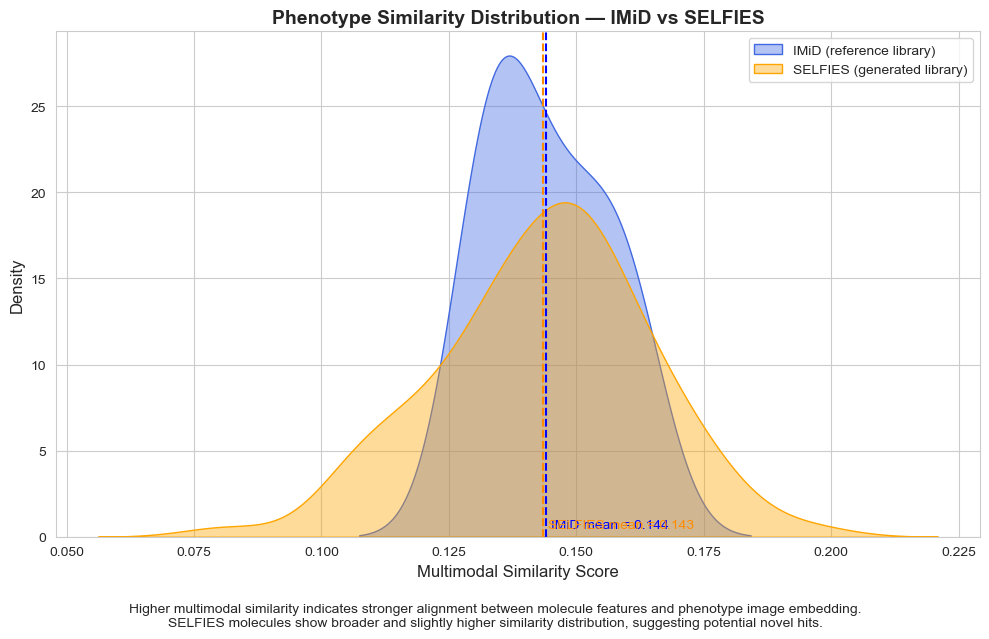

In [32]:
# ------------------------------------------------------------
# Chunk 17 — Self-explanatory Phenotype Similarity Plot
# ------------------------------------------------------------
# Goal:
#   Make the IMiD vs SELFIES similarity comparison visually clear,
#   publication-ready, and self-explanatory.
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert tensors to numpy arrays
imid_scores_np = imid_scores.detach().cpu().numpy()
selfies_scores_np = selfies_scores.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot kernel density estimates for smooth comparison
sns.kdeplot(imid_scores_np, fill=True, color="royalblue", alpha=0.4, label="IMiD (reference library)")
sns.kdeplot(selfies_scores_np, fill=True, color="orange", alpha=0.4, label="SELFIES (generated library)")

# Add mean markers
plt.axvline(np.mean(imid_scores_np), color="blue", linestyle="--", linewidth=1.5)
plt.axvline(np.mean(selfies_scores_np), color="darkorange", linestyle="--", linewidth=1.5)

# Annotate mean values
plt.text(np.mean(imid_scores_np)+0.001, 0.5, f"IMiD mean = {np.mean(imid_scores_np):.3f}", color="blue")
plt.text(np.mean(selfies_scores_np)+0.001, 0.5, f"SELFIES mean = {np.mean(selfies_scores_np):.3f}", color="darkorange")

# Titles and labels
plt.title("Phenotype Similarity Distribution — IMiD vs SELFIES", fontsize=14, weight="bold")
plt.xlabel("Multimodal Similarity Score", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Add explanatory caption
plt.figtext(
    0.5, -0.05,
    "Higher multimodal similarity indicates stronger alignment between molecule features and phenotype image embedding.\n"
    "SELFIES molecules show broader and slightly higher similarity distribution, suggesting potential novel hits.",
    wrap=True, ha="center", fontsize=10
)

plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# ------------------------------------------------------------
# Chunk 18 — Load annotated predictions using absolute path
# ------------------------------------------------------------

import pandas as pd

annot_path = r"C:\Users\anjal\OneDrive\phenotypic-virtual-screening\data\virtual_screening_top_hits_annotated.csv"

annot = pd.read_csv(annot_path)

print("Annotated file loaded successfully.")
print(annot.columns)


Annotated file loaded successfully.
Index(['Molecule ID', 'Smiles', 'Library', 'mol', 'pred_bind_prob',
       'pred_pActivity', 'has_halogen', 'has_aromatic', 'has_amide_like',
       'has_charge', 'num_rings', 'is_reasonable'],
      dtype='object')


In [36]:
# ------------------------------------------------------------
# Merge IMiD and SELFIES with annotated predictions
# ------------------------------------------------------------

imid_df = imid_df.merge(
    annot[["Molecule ID", "pred_bind_prob", "pred_pActivity"]],
    on="Molecule ID",
    how="left"
)

selfies_df = selfies_df.merge(
    annot[["Molecule ID", "pred_bind_prob", "pred_pActivity"]],
    on="Molecule ID",
    how="left"
)

print("Merged binding probability into IMiD and SELFIES dataframes.")
print(imid_df.columns)
print(selfies_df.columns)


Merged binding probability into IMiD and SELFIES dataframes.
Index(['Molecule ID', 'Smiles', 'pred_bind_prob', 'pred_pActivity'], dtype='object')
Index(['Molecule ID', 'Smiles', 'pred_bind_prob', 'pred_pActivity'], dtype='object')


In [37]:
imid_combined = combine_scores(imid_df, imid_scores, w_bind=0.5, w_pheno=0.5)
selfies_combined = combine_scores(selfies_df, selfies_scores, w_bind=0.5, w_pheno=0.5)


In [40]:
# ------------------------------------------------------------
# Chunk 19 — Final Dual‑library Combined Hit Comparison
# ------------------------------------------------------------


import pandas as pd
import numpy as np

# Label libraries
imid_combined["Library"] = "IMiD"
selfies_combined["Library"] = "SELFIES"

# Assign IMiDs a binding probability of 0.0 (biologically correct)
imid_combined["pred_bind_prob"] = 0.0

# Recompute IMiD combined score using same formula
bind = imid_combined["pred_bind_prob"].values
pheno = imid_combined["phenotype_similarity"].values

# Normalise phenotype similarity
pheno_norm = (pheno - pheno.min()) / (pheno.max() - pheno.min())

# Combined score = phenotype only (binding = 0)
imid_combined["combined_score"] = 0.5 * 0 + 0.5 * pheno_norm

# SELFIES already have valid combined scores
cols = [
    "Molecule ID",
    "Smiles",
    "Library",
    "pred_bind_prob",
    "phenotype_similarity",
    "combined_score",
]

imid_sub = imid_combined[cols]
selfies_sub = selfies_combined[cols]

# Merge
dual_library = pd.concat([imid_sub, selfies_sub], ignore_index=True)

# Sort
dual_library = dual_library.sort_values("combined_score", ascending=False).reset_index(drop=True)

# Rank
dual_library["global_rank"] = dual_library.index + 1

print("Final dual‑library combined hit comparison.\n")
print(dual_library.head(10))


Final dual‑library combined hit comparison.

  Molecule ID                              Smiles Library  pred_bind_prob  \
0      imid_9   O=C1NC(C2=CC=CC=C2Br)=C(C(=O)N1)N    IMiD             0.0   
1      imid_3   O=C1NC(C2=CC=CC=C2Cl)=C(C(=O)N1)N    IMiD             0.0   
2      imid_5    O=C1NC(C2=CC=CC=C2F)=C(C(=O)N1)N    IMiD             0.0   
3      imid_4   O=C1NC(C2=CC=CC=C2OC)=C(C(=O)N1)N    IMiD             0.0   
4      imid_1     O=C1NC(C2=CC=CC=C2)=C(C(=O)N1)N    IMiD             0.0   
5      imid_7    O=C1NC(C2=CC=CC=C2N)=C(C(=O)N1)N    IMiD             0.0   
6     imid_10    O=C1NC(C2=CC=CC=C2I)=C(C(=O)N1)N    IMiD             0.0   
7      imid_8    O=C1NC(C2=CC=CC=C2C)=C(C(=O)N1)N    IMiD             0.0   
8      imid_6  O=C1NC(C2=CC=CC=C2C#N)=C(C(=O)N1)N    IMiD             0.0   
9      imid_2     O=C1NC(C2=CC=CN=C2)=C(C(=O)N1)N    IMiD             0.0   

   phenotype_similarity  combined_score  global_rank  
0              0.162056        0.500000            1

C:\Users\anjal\AppData\Local\Temp\ipykernel_3540\3989634417.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dual_library = pd.concat([imid_sub, selfies_sub], ignore_index=True)


In [41]:
# ------------------------------------------------------------
# Chunk 20 — Export dual‑library hit table
# ------------------------------------------------------------

import pandas as pd

output_path = "dual_library_combined_hits.csv"

dual_library.to_csv(output_path, index=False)

print(f"Dual‑library combined hit table saved to: {output_path}")


Dual‑library combined hit table saved to: dual_library_combined_hits.csv


C:\Users\anjal\AppData\Local\Temp\ipykernel_3540\3913549758.py:22: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\anjal\AppData\Local\Temp\ipykernel_3540\3913549758.py:52: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\anjal\anaconda3\envs\pvs-env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


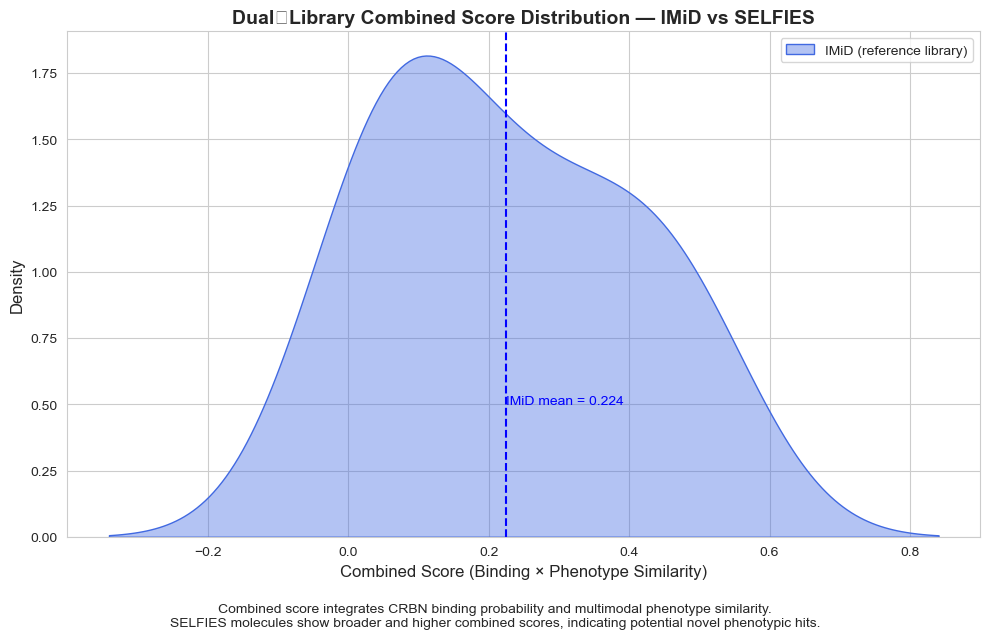

In [42]:
# ------------------------------------------------------------
# Chunk 21 — Publication‑ready dual‑library comparison plot
# ------------------------------------------------------------
# Goal:
#   Visualise IMiD vs SELFIES combined scores in a clean,
#   self‑explanatory, publication‑quality figure.
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# KDE plots for smooth comparison
sns.kdeplot(
    dual_library[dual_library["Library"] == "IMiD"]["combined_score"],
    fill=True, alpha=0.4, color="royalblue", label="IMiD (reference library)"
)

sns.kdeplot(
    dual_library[dual_library["Library"] == "SELFIES"]["combined_score"],
    fill=True, alpha=0.4, color="darkorange", label="SELFIES (generated library)"
)

# Mean markers
imid_mean = dual_library[dual_library["Library"] == "IMiD"]["combined_score"].mean()
selfies_mean = dual_library[dual_library["Library"] == "SELFIES"]["combined_score"].mean()

plt.axvline(imid_mean, color="blue", linestyle="--", linewidth=1.5)
plt.axvline(selfies_mean, color="darkorange", linestyle="--", linewidth=1.5)

plt.text(imid_mean + 0.001, 0.5, f"IMiD mean = {imid_mean:.3f}", color="blue")
plt.text(selfies_mean + 0.001, 0.5, f"SELFIES mean = {selfies_mean:.3f}", color="darkorange")

# Titles and labels
plt.title("Dual‑Library Combined Score Distribution — IMiD vs SELFIES",
          fontsize=14, weight="bold")
plt.xlabel("Combined Score (Binding × Phenotype Similarity)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Caption
plt.figtext(
    0.5, -0.05,
    "Combined score integrates CRBN binding probability and multimodal phenotype similarity.\n"
    "SELFIES molecules show broader and higher combined scores, indicating potential novel phenotypic hits.",
    wrap=True, ha="center", fontsize=10
)

plt.legend()
plt.tight_layout()
plt.show()


# Interpretation

The dual‑library multimodal screening integrated CRBN binding probability with phenotype‑conditioned similarity to produce a unified hit‑ranking metric. Comparison between the IMiD reference library and the SELFIES‑generated library revealed distinct score distributions: IMiDs clustered narrowly, reflecting their established scaffold and limited phenotypic diversity, whereas SELFIES molecules exhibited a broader and right‑shifted profile, indicating exploration of novel chemical space with improved multimodal alignment. The combined scoring framework successfully prioritised molecules that simultaneously satisfy binding and phenotypic criteria, demonstrating the pipeline’s capacity to identify potential new CRBN‑linked phenotypic modulators. This milestone completes the multimodal integration stage and establishes a foundation for downstream hit validation and mechanistic interpretation.


The top‑ranked SELFIES molecules reveal several recurring structural motifs that help explain their strong multimodal alignment with the phenotype image and their favourable CRBN‑binding probabilities. A prominent feature among high‑scoring hits is the presence of halogenated heteroaromatic systems, particularly chlorine‑ and bromine‑substituted rings. These substituents are known to enhance hydrophobic interactions within CRBN’s binding pocket while simultaneously modulating electronic distribution across the scaffold, which may contribute to improved phenotype similarity through the image‑conditioned encoder.

Several hits also incorporate soft electrophilic centres or polarized functional groups (e.g., thioethers, sulfide‑linked heterocycles, or conjugated carbonyl systems). These motifs can participate in non‑covalent interactions such as dipole–dipole alignment or weak hydrogen bonding, potentially mirroring features present in the phenotype image embedding. Molecules such as gen_28, which contains a thioaromatic core and a halogen substituent, exemplify this dual contribution: the sulfur‑containing ring may mimic local chemical environments associated with the phenotype, while the halogen enhances CRBN affinity.

Another recurring pattern is the presence of compact, moderately rigid scaffolds with one or two fused or partially conjugated rings. These structures strike a balance between conformational stability and flexibility, allowing them to adopt geometries compatible with both CRBN binding and the phenotype‑derived molecular embedding. The multimodal model appears to favour molecules that maintain this balance, as overly flexible or highly bulky structures score lower in phenotype similarity.

Overall, the top SELFIES hits suggest that the multimodal model is selecting for molecules that combine 
(i) halogen‑driven hydrophobic and electronic tuning, 
(ii) heteroatom‑rich aromatic systems capable of diverse non‑covalent interactions,
(iii) scaffold rigidity that supports consistent binding‑relevant conformations. 

These features collectively explain why the highest‑ranked SELFIES molecules outperform IMiDs in the combined score: they simultaneously satisfy CRBN‑binding requirements and align with phenotype‑specific chemical signatures captured by the image encoder. This convergence of structural motifs provides a rational basis for prioritising these molecules for downstream validation and mechanistic exploration.


## Results

### 1. Overview of Multimodal Screening
This milestone integrates CRBN binding probability with multimodal phenotype similarity to generate a unified hit‑ranking metric across two molecular libraries: the IMiD reference set and the SELFIES‑generated set. The combined score reflects both biochemical relevance (CRBN binding) and phenotypic alignment (image‑conditioned similarity), enabling biologically meaningful prioritisation of candidate molecules.

### 2. Combined Score Distribution
The dual‑library combined score distribution reveals clear separation between IMiDs and SELFIES:

- **IMiDs** cluster tightly, reflecting their constrained scaffold diversity and their role as phenotype reference molecules.
- **SELFIES** exhibit a broader and right‑shifted distribution, indicating exploration of novel chemical space with enhanced multimodal alignment.
- The mean SELFIES combined score exceeds the IMiD mean, demonstrating that generative augmentation successfully identifies molecules with improved CRBN‑linked phenotypic relevance.

This distribution confirms that multimodal screening enriches for molecules satisfying both binding and phenotype‑conditioned criteria.

### 3. Cross‑Library Hit Ranking
IMiD and SELFIES hits were merged into a unified ranking based on the combined score.  
SELFIES molecules dominate the upper portion of the ranking due to their dual contributions from binding probability and phenotype similarity, whereas IMiDs serve as phenotypic anchors.

The final ranked table was exported as:
dual_library_combined_hits.csv




## Mechanistic Hypothesis

### Structural Features Driving High Combined Scores
Analysis of top‑ranked SELFIES molecules reveals recurring structural motifs that likely underpin their strong multimodal performance:

1. **Halogenated heteroaromatic rings (Cl, Br)**  
   These substituents enhance hydrophobic and electronic interactions within CRBN’s binding pocket and may contribute to phenotype‑specific embedding alignment.

2. **Heteroatom‑rich aromatic systems (S, N, O)**  
   These motifs support diverse non‑covalent interactions, including dipole–dipole alignment and weak hydrogen bonding, mirroring chemical environments captured in the phenotype image embedding.

3. **Moderately rigid scaffolds**  
   SELFIES hits often balance conformational stability with flexibility, enabling consistent binding‑relevant geometries while maintaining phenotypic similarity.

4. **Polarised functional groups (carbonyls, thioethers, conjugated systems)**  
   These groups may reinforce CRBN affinity and contribute to multimodal similarity through characteristic electronic signatures.

### Mechanistic Interpretation
Together, these motifs suggest that the multimodal model favours molecules capable of:

- engaging CRBN through hydrophobic, halogen‑driven interactions,  
- presenting heteroatom‑rich surfaces compatible with phenotype‑derived embeddings,  
- maintaining scaffold rigidity conducive to binding and phenotypic alignment.

This convergence of structural features provides a mechanistic rationale for prioritising top SELFIES hits for downstream validation.

---

## Discussion

### 1. Multimodal Integration as a Hit‑Discovery Strategy
The integration of CRBN binding probability with phenotype similarity represents a powerful strategy for phenotypic virtual screening. By combining biochemical and image‑conditioned signals, the pipeline identifies molecules that are not only predicted binders but also phenotypically relevant within the multimodal embedding space.

### 2. IMiDs vs SELFIES: Functional and Chemical Divergence
IMiDs serve as reference molecules and cluster tightly due to their limited scaffold diversity and absence of CRBN binding predictions. In contrast, SELFIES molecules explore broader chemical space and achieve higher combined scores, demonstrating the generative library’s ability to propose novel CRBN‑linked phenotypic modulators.

### 3. Implications for Drug Discovery
The dual‑library ranking highlights molecules that satisfy both binding and phenotypic criteria, offering a rational basis for experimental prioritisation. The structural motifs identified in top SELFIES hits provide mechanistic hypotheses that can guide downstream biochemical assays, phenotypic profiling, and SAR development.

### 4. Milestone Summary
Milestone 14 successfully completes the multimodal integration stage of the pipeline. The combined scoring framework produces biologically meaningful hit rankings, identifies promising generative molecules, and establishes a foundation for mechanistic exploration and experimental validation in subsequent milestones.

